# SYNTHETIC CELL GENERATION

This notebook aims to generate sample images to mimic that of a handwritten cell of one of the 18 holes in a golf scorecard.

It fuses the following:

- MNIST number images (main number + superscript)
- Handdrawn circles, triangles, squares (cv2's shapes are too deterministic)

The combined output goes through a conversion to look real (pencil ink and rough paper), through Gaussian blur and tweaking the text and background colors.

All generated samples are of size 48 x 48.

**Bulk generation**

Synthetic samples are saved as `.png` files in an "images" folder in `"syn_cell_dataset/set[i]"`, whose corresponding labels are integers saved in `"labels.csv"`. 

The labels file consists of the columns:
- "image" stores the filenames of each synthetic sample, including the extension `.png`.
- "label" stores the main number of the synthetic sample (requires to be converted to `int` when read).

In [1]:
import cv2
from PIL import Image
import os, sys
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io, filters, color, transform, feature, exposure, segmentation, graph, morphology, restoration, measure
from scipy import ndimage as ndi
import math
import torch
from torchvision import datasets, transforms
import numpy as np
import importlib

PROJECT_ROOT = Path().resolve().parent
print(PROJECT_ROOT)
print(torch.cuda.get_device_name(torch.cuda.current_device()))
print("Torch version", torch.__version__)

sys.path.insert(0, str(PROJECT_ROOT))

from scripts.constants import TABLE_LINE_INTENSITY

E:\work\Golf\GolfScoreCards
NVIDIA GeForce RTX 2070 Super
Torch version 2.5.1+cu121


In [2]:
mnist = datasets.MNIST(root='./mnist-emnist_data', train=True, download=True)
digits_imgs = mnist.data.numpy()
digits_labels = mnist.targets.numpy()

emnist = datasets.EMNIST(root='./mnist-emnist_data', split='byclass', train=True, download=True)
letters_imgs = emnist.data.numpy()
letters_labels = emnist.targets.numpy()

## Hole Cell Sample Generation

In [3]:
STAMP_PATH = "..\\data\\Stamps"
stamps_f = [f for f in os.listdir(STAMP_PATH)]
stamps = {}
stamps['circ'] = [os.path.join(STAMP_PATH, f) for f in stamps_f if "circ" in f]
stamps['tri'] = [os.path.join(STAMP_PATH, f) for f in stamps_f if "tri" in f]
stamps['sq'] = [os.path.join(STAMP_PATH, f) for f in stamps_f if "sq" in f]

Number: 7


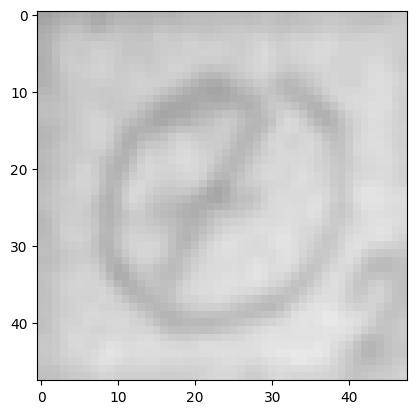

In [135]:
def get_digit_img(val:int, t_size=48):
    """
    Returns [t_size]x[t_size] image with single digit
    """
    idx = np.random.choice(np.where(digits_labels == val)[0])
    img = digits_imgs[idx]
    img_resized = cv2.resize(img, (t_size, t_size), interpolation=cv2.INTER_CUBIC)
    return img_resized

def shrink_and_place(img, min_scale=0.75, max_scale=0.9):
    """
    Returns 28x28 image (with single digit)
    """
    H, W = img.shape
    scale = np.random.uniform(min_scale, max_scale)
    new_h = max(1, int(H * scale))
    new_w = max(1, int(W * scale))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized

def get_sample(val:int, y_chamb=0, t_size=48):
    
    cell_w = np.random.randint(48,54)
    canvas = np.zeros((48,cell_w))
    H, W = canvas.shape
    main = get_digit_img(val, t_size=28)
    main = get_digit_img(val)
    main = shrink_and_place(main, min_scale=0.75, max_scale=0.8)
    mh, mw = main.shape
    max_h, max_w = max(1, (H*0.9) - mh), max(1, (W*0.9) - mw)
    start_h, start_w = np.random.randint(0, max_h), np.random.randint(0, max_w)
    canvas[start_h:start_h+mh, start_w:start_w+mw] = main

    v = np.random.randint(0,4)
    sup = get_digit_img(v)
    sup = shrink_and_place(sup, min_scale=0.3, max_scale=0.5)
    sh, sw = sup.shape

    low_x = int(0.7 * W)
    high_x = max(low_x + 1, W - sw)
    start_x = np.random.randint(low_x, high_x)
    if y_chamb == 0:  # top
        low_y = 0
        high_y = max(1, int(0.4 * H) - sh)
        start_y = np.random.randint(low_y, high_y)
    else:   # bottom
        low_y = int(0.6 * H)
        high_y = max(low_y + 1, H - sh)
        start_y = np.random.randint(low_y, high_y)
    end_y = min(H, start_y + sh)
    end_x = min(W, start_x + sw)
    sup_slice = sup[:(end_y - start_y), :(end_x - start_x)]
    canvas[start_y:start_y+sh, start_x:start_x+sw] = np.maximum(canvas[start_y:end_y, start_x:end_x], sup_slice)
    return canvas

def add_scribble(img, n_lines=5):
    h, w = img.shape
    for _ in range(n_lines):
        x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
        x2, y2 = np.random.randint(0, w), np.random.randint(0, h)
        thickness = np.random.randint(1, 3)
        color = np.random.randint(100, 180)
        cv2.line(img, (x1, y1), (x2, y2), color, thickness)
    return img

def apply_simple_stamp(digit_img, stamp_path):
    """
    digit_img: 48x48 numpy array (the number)
    stamp_path: path to your 60x60 stamp image
    """
    # 1. & 2. Load and rescale to 48x48
    h, w = digit_img.shape
    stamp = cv2.imread(stamp_path, cv2.IMREAD_GRAYSCALE)
    stamp = cv2.resize(stamp, (w, h), interpolation=cv2.INTER_AREA)

    # 3. Binarize
    # We want to find the "ink". If background is white (255) and ink is dark (<100),
    # anything dark becomes the foreground.
    _, mask = cv2.threshold(stamp, 180, 255, cv2.THRESH_BINARY_INV)
    stamp = 255 - stamp
    brightness = np.random.randint(120,160)
    boost = np.zeros_like(stamp)
    boost[mask > 0] = brightness
    stamp = np.clip(stamp.astype(np.uint32) + boost, 0, 255).astype(np.uint8)

    out = np.maximum(digit_img, stamp)
    
    return out

def binary_to_soft_grayscale(img, bg_range=(200, 240), text_range=(180, 190), noise_std=2.0, shading_strength=10.0, blur_ksize=3, blur_sigma=0.8, min_contrast=15):
    """
    Convert a binary image to a soft grayscale image with realistic variation.

    Parameters
    ----------
    img : np.ndarray
        Binary image (H, W), values in {0,1} or {0,255}
        Text pixels are assumed to be foreground (1 or 255).
    bg_range : tuple
        (min, max) grayscale range for background
    text_range : tuple
        (min, max) grayscale range for text
    noise_std : float
        Std of additive Gaussian noise
    shading_strength : float
        Amplitude of low-frequency background shading

    Returns
    -------
    gray : np.ndarray
        Grayscale uint8 image in [0,255]
    """

    img = img.astype(np.float32)
    if img.max() > 1: img /= 255.0
    img[img < 0.05] = 0

    h, w = img.shape

    if blur_ksize > 1: img = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), blur_sigma)
    # img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    bg_gray = np.random.uniform(*bg_range)
    text_gray = np.random.uniform(*text_range)

    # enforce minimum contrast
    if abs(bg_gray - text_gray) < min_contrast:
        if text_gray < bg_gray: text_gray = bg_gray - min_contrast
        else: text_gray = bg_gray + min_contrast

    # clamp to valid range
    text_gray = np.clip(text_gray, 0, 255)
    gray = img * (text_gray - bg_gray) + bg_gray

    # Smooth low-frequency shading
    yy, xx = np.meshgrid(np.linspace(-1, 1, h), np.linspace(-1, 1, w), indexing="ij")
    shading = np.random.uniform(-shading_strength, shading_strength) * (xx + yy)
    gray += shading

    # Add mild noise
    if noise_std > 0: gray += np.random.normal(0, noise_std, size=gray.shape)
    return np.clip(gray, 0, 255).astype(np.uint8)

def add_edge_shade(canvas, width=2):
    H, W = canvas.shape
    # Create a gradient from 0 to 200
    grad = np.linspace(0, 200, width).astype(np.uint8)

    canvas[:, :width] = np.maximum(canvas[:, :width], grad)                  # left edge
    canvas[:, W-width:] = np.maximum(canvas[:, W-width:], grad)              # right edge
    canvas[:width, :] = np.maximum(canvas[:width, :], grad[:, None])       # top edge
    canvas[H-width:, :] = np.maximum(canvas[H-width:, :], grad[:, None])   # bottom edge
        
    return canvas

main_num = np.random.randint(1,10)
print(f"Number: {main_num}")
cell = get_sample(main_num, y_chamb=1)
cell = apply_simple_stamp(cell, stamps['circ'][0])
cell = add_edge_shade(cell, width=2)
cell = binary_to_soft_grayscale(cell, bg_range=(200, 235), text_range=(160, 190), noise_std=10.0, shading_strength=20.0, blur_ksize=11, blur_sigma=0.8)
cell = cv2.GaussianBlur(cell, (5,5), 1.0)
cell = cell.astype(np.uint8)
plt.imshow(cell, cmap='gray', vmin=0, vmax=255)   # matplotlib auto-stretches contrast
# plt.imshow(cell, cmap='gray')

Number: 1


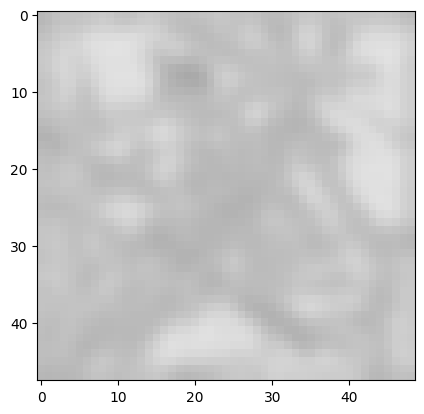

In [16]:
# cell scribbled over
main_num = np.random.randint(1,10)
print(f"Number: {main_num}")
cell = get_sample(main_num, y_chamb=1)
cell = add_scribble(cell, n_lines=45)
# cell = apply_simple_stamp(cell, stamps['circ'][0])
cell = add_edge_shade(cell, width=2)
cell = binary_to_soft_grayscale(cell, bg_range=(220, 245), text_range=(150, 170), noise_std=5.0, shading_strength=12.0, blur_ksize=11, blur_sigma=0.8)
cell = cv2.GaussianBlur(cell, (5,5), 1.0)
cell = cell.astype(np.uint8)
plt.imshow(cell, cmap='gray', vmin=0, vmax=255)

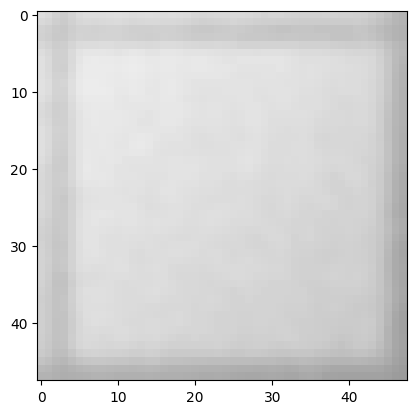

In [17]:
# empty cell
cell = np.zeros((48,48))
cell = add_edge_shade(cell, width=4)
cell = binary_to_soft_grayscale(cell, bg_range=(220, 245), text_range=(150, 170), noise_std=5.0, shading_strength=12.0, blur_ksize=11, blur_sigma=0.8)
cell = cv2.GaussianBlur(cell, (5,5), 1.0)
cell = cell.astype(np.uint8)
plt.imshow(cell, cmap='gray', vmin=0, vmax=255)

## Synthetic Cell Bulk Generation

In [137]:
from tqdm import tqdm
import csv
import importlib
import scripts.utils
importlib.reload(scripts.utils)
from scripts.utils import get_last_index

def bulk_gen_samples(out_dir, conf:dict, N=10000):
    os.makedirs(out_dir, exist_ok=True)
    img_path = os.path.join(out_dir, 'images')
    lbl_path = os.path.join(out_dir, 'labels.csv')
    if not os.path.exists(lbl_path): write_header = True
    os.makedirs(img_path, exist_ok=True)
    if not os.listdir(img_path): dir_idx = 0
    else: dir_idx = get_last_index(img_path, level='sample') + 1

    with open(lbl_path, "a", newline="") as label_file:
        writer = csv.writer(label_file)
        if write_header: writer.writerow(["image", "label"])  # write column headers
        for n in tqdm(range(N), desc='Generating synthetic cell dataset'):
            main_num = np.random.choice(conf['classes'], p=conf['class_dist'])
            if main_num == '-':
                cell = np.zeros(conf['cell_shape'])
                # if np.random.rand() < 0.2: 
                #     cell = get_sample(np.random.choice(np.arange(1,10)), y_chamb=np.random.randint(0,2))
                #     cell = add_scribble(cell, n_lines=np.random.randint(*conf['scribble_range']))
            else:
                key = np.random.choice(["circ", "tri", "sq", None], p=[0.3, 0.2, 0.1, 0.4])
                stamp_path = None if key is None else np.random.choice(stamps[key])
                cell = get_sample(int(main_num), y_chamb=np.random.randint(0,2))
                if stamp_path: cell = apply_simple_stamp(cell, stamp_path)

            cell = add_edge_shade(cell, width=np.random.randint(*conf['edge_width_range']))
            cell = binary_to_soft_grayscale(cell, bg_range=conf['bg_range'], text_range=conf['text_range'], noise_std=conf['noise_std'], shading_strength=conf['shading_strength'], blur_ksize=conf['blur_ksize'], blur_sigma=conf['blur_sigma'], min_contrast=conf['min_contrast'])
            cell = cv2.GaussianBlur(cell, (5,5), 1.0)
            cell = cell.astype(np.uint8)

            f_name = f"img_{dir_idx + n}.jpeg"
            img_filename = os.path.join(img_path, f_name) 
            cv2.imwrite(img_filename, cell)
            writer.writerow([f_name, main_num])

config = {
    'classes': ['-'] + list(np.arange(1,10)),
    'class_dist': [0.12, 0.11, 0.11, 0.10, 0.10, 0.08, 0.09, 0.10, 0.10, 0.09],
    'cell_shape': (48,48),
    'edge_width_range': (2,6),
    'scribble_range': (30,50),
    'text_range': (150, 190),
    'bg_range': (200, 235),
    'noise_std': 5.0, 'shading_strength': 12.0, 'blur_ksize': 11, 'blur_sigma': 0.8,
    'min_contrast': 15
}
dataset_path = 'syn_cell_dataset'
syn_path = os.path.join(PROJECT_ROOT, dataset_path)
new_set = 'set{k}'
# new_set = 'set1'
last_i = get_last_index(syn_path, level='dataset')
i = last_i + 1 if last_i is not None else 0
# i = 0
new_set_dir = os.path.join(PROJECT_ROOT, dataset_path, new_set.format(k=i))
print(f"New dataset generated at {new_set_dir}")
bulk_gen_samples(new_set_dir, config, N=20000)

New dataset generated at E:\work\Golf\GolfScoreCards\syn_cell_dataset\set2


Generating synthetic cell dataset: 100%|██████████| 20000/20000 [00:33<00:00, 598.13it/s]


In [138]:
import pandas as pd

df_labels = pd.read_csv('../syn_cell_dataset/set2/labels.csv', sep=',')
df_labels.value_counts('label')

label
-    2383
2    2184
1    2136
3    2041
7    2017
8    2015
4    2001
9    1785
6    1774
5    1664
Name: count, dtype: int64